In [6]:
# imports
import os
import sys
sys.path.append(os.path.abspath(".."))
from src.data.data_loader import DataLoad
from src.data.hpt_dataset import HPTDataset
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, HuberRegressor
from sklearn.dummy import DummyRegressor
from sklearn.base import clone
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats.mstats import spearmanr
from itertools import product
from joblib import Parallel, delayed
from xgboost import XGBRegressor
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import optuna
import torch.optim as optim
from ast import literal_eval
import warnings

warnings.filterwarnings(
    "ignore",
    message="Got `batch_size` less than 1 or larger than sample size.*",
    category=UserWarning,
    module="sklearn.neural_network._multilayer_perceptron"
)

np.random.seed(42)
torch.manual_seed(42)

In [7]:
# play around to create rolling window backtest, ensuring no data leakage

dl = DataLoad()
df = dl.load_single_data("transformed","Dataset")

Dataset.csv loaded succesfully


In [8]:
df = df.loc[:'2016-12-31']
features = [c for c in df.columns if c not in ["Ticker", "Target"]]
df_train = df[df.index <= "2015-12-31"]
X_train = df_train[features].to_numpy()
y_train = df_train["Target"].to_numpy()

In [9]:
# first of all will implement own scoring, not for training but for model evaluation
# as we will be creating weighted portfolios based on predictions both magnitude and direction are important
# so scoring will be a mix of both spearmen IC and directional accuracy
# DA is simply a sign check, when positive does model predict positive, when negative does model predict negative
# its a proportion between 0 - 1, therefore will subtract 0.5 and multiply by 2, to center it at 0 and be [-1,1]
# use IC instead of R^2 as its less sensitive to scale, will use spearmen as its less prone to outliers
# so scoring will be  0.6 * IC(spearmen) + 0.4 * DA(centered)
# Balanced Information & Directional Score (BIDS)

def bids(y_pred, y_true):

    rank_ic, _ = spearmanr(y_true,y_pred)
    if np.isnan(rank_ic):
        rank_ic = 0

    directional_accuracy = np.mean(np.sign(y_true) == np.sign(y_pred))
    da_centered = 2 * (directional_accuracy - 0.5)

    return 0.6 * rank_ic + 0.4 * da_centered

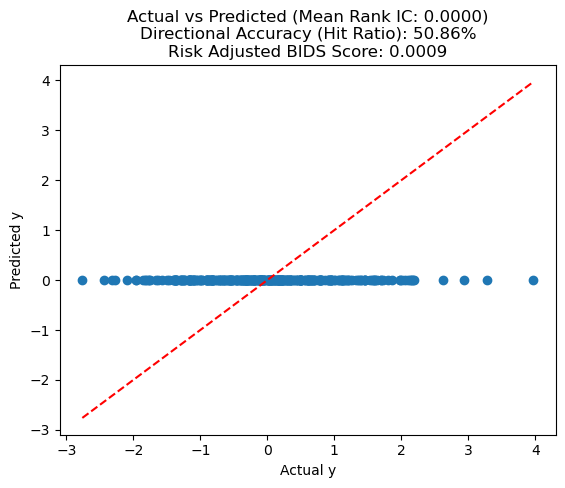

In [13]:
# as a baseline, predict the mean always
# setup a rolling walk forward evaluation for the evaluation set
#similar to how the real backtest will be

model = DummyRegressor(strategy="mean")

val_months = df[df.index > "2015-12-31"].index.unique().to_numpy()

y_preds = []
y_trues = []
for month in val_months:

    x_fit = df[df.index < month][features].to_numpy()
    y_fit = df[df.index < month]["Target"].to_numpy()
    model.fit(x_fit, y_fit)

    x_val = df[df.index == month][features].to_numpy()
    y_val = df[df.index == month]["Target"].to_numpy()
    y_preds.append(model.predict(x_val))
    y_trues.append(y_val)

ics = [spearmanr(y_pred,y_true)[0] for y_pred,y_true in zip(y_preds,y_trues)]
bids_scores = [bids(y_pred,y_true) for y_pred,y_true in zip(y_preds,y_trues)]
mu = np.mean(bids_scores)
sigma = np.std(bids_scores) + 1e-6
# Return the Risk-Adjusted BIDS, this favors high-performing models that don't fluctuate wildly month-to-month
ra_bids = mu * (mu / sigma)

y_pred = np.concatenate(y_preds)
y_true = np.concatenate(y_trues)

plt.scatter(y_true, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_true.min(), y_true.max()], [y_true.min(),y_true.max()], 'r--')
sign_accuracy = np.mean(np.sign(y_true) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (Mean Rank IC: {np.mean(ics):.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}\nRisk Adjusted BIDS Score: {ra_bids:.4f}")
plt.show()

                            feature  coefficient  non_zero
0           Semi-annual Log Returns    -0.019973      True
1                             VMA60    -0.053881      True
2         Percentage Intraday Range    -0.076007      True
3                     Average Gains     0.066958      True
4                    Average Losses    -0.070261      True
5                                RS    -0.070311      True
6           10-day Efficiency Ratio     0.014903      True
7                           Body Up    -0.055699      True
8                         Body Down    -0.049672      True
9          Monthly Conviction Ratio     0.067876      True
10         Volatility of Volatility    -0.054627      True
11  Volatility Term Structure Slope     0.027607      True
12               Return Autocorr 5D     0.018689      True
13              Return Autocorr 10D     0.045493      True
14      Monthly Return Acceleration    -0.054709      True
15                   Trend Strength    -0.105335      Tr

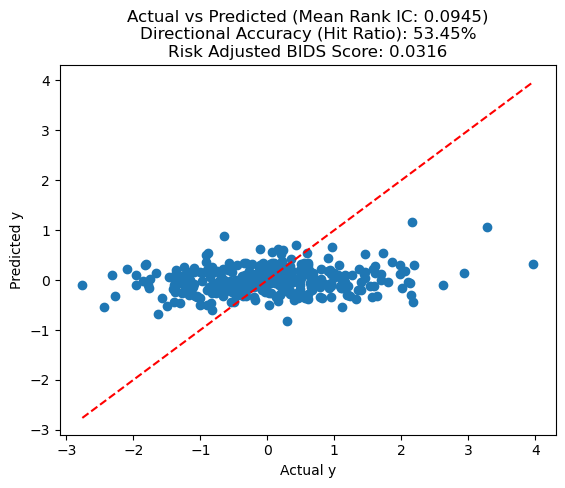

In [14]:
# try linear models

model = LinearRegression(n_jobs=-1)
model.fit(X_train,y_train)

coefs = model.coef_
coef_table = pd.DataFrame({
    'feature': df[features].columns,
    'coefficient': coefs,
    'non_zero': coefs != 0
})
print(coef_table)


y_preds = []
y_trues = []
for month in val_months:

    x_fit = df[df.index < month][features].to_numpy()
    y_fit = df[df.index < month]["Target"].to_numpy()
    model.fit(x_fit, y_fit)

    x_val = df[df.index == month][features].to_numpy()
    y_val = df[df.index == month]["Target"].to_numpy()
    y_preds.append(model.predict(x_val))
    y_trues.append(y_val)

ics = [spearmanr(y_pred,y_true)[0] for y_pred,y_true in zip(y_preds,y_trues)]
bids_scores = [bids(y_pred,y_true) for y_pred,y_true in zip(y_preds,y_trues)]
mu = np.mean(bids_scores)
sigma = np.std(bids_scores) + 1e-6
# Return the Risk-Adjusted BIDS, this favors high-performing models that don't fluctuate wildly month-to-month
ra_bids = mu * (mu / sigma)

y_pred = np.concatenate(y_preds)
y_true = np.concatenate(y_trues)

plt.scatter(y_true, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_true.min(), y_true.max()], [y_true.min(),y_true.max()], 'r--')
sign_accuracy = np.mean(np.sign(y_true) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (Mean Rank IC: {np.mean(ics):.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}\nRisk Adjusted BIDS Score: {ra_bids:.4f}")
plt.show()

In [15]:
# create hyper parameter search, must create custom scaler + custom pipe + custom grid search
# sklearn default pipes and timeseries splits and grid search doesnt work with how my current dataset is created
# we dont have a "test" data so to speak, the prediction we test on (log returns of the next month) are part of the row of data we use to predict
# our predictions are dephased by 1 month
# expanding-window, one-step-ahead forecasting where the prediction is made on the latest available row (not the next row)
# sklearn packages would treat this last row as "test" data, which wouldnt be correct 

class RollingGridSearch():
    """
    Rolling-window grid search for time-series / expanding window prediction.
    """

    def __init__(self, model, param_grid, min_train_size=24, n_jobs=-1, verbose=1):

        self.model = model
        self.param_grid = param_grid
        self.scorer_ = bids
        self.min_train_size = min_train_size
        self.n_jobs = n_jobs
        self.verbose = verbose

    def _param_combinations(self):
        keys, values = list(self.param_grid.keys()), list(self.param_grid.values())
        for combo in product(*values):
            yield dict(zip(keys, combo))

    def _evaluate_params(self, params, X, y):
        scores = []
        model_step = clone(self.model)
        model_step.set_params(**params)

        for t in range(max(1, self.min_train_size), len(X)):

            X_prev = X[t-1]
            X_curr = X[t]

            n_prev = len(X_prev)

            X_train = X_curr[:n_prev]
            y_train = y[:n_prev]

            X_test = X_curr[n_prev:]
            y_test = y[n_prev:len(X_curr)]

            if len(X_test) == 0:
                continue

            model_step.fit(X_train, y_train)
            y_pred = model_step.predict(X_test)
            
            score = self.scorer_(y_pred, y_test)
            scores.append(score)

        mu = np.mean(scores)
        sigma = np.std(scores) + 1e-6
        score = mu * (mu / sigma) # Risk-Adjusted BIDS, will help find more stable parameters, instead of just the peak
        return {"params": params, "score": score}

    def fit(self, X, y):
        param_list = list(self._param_combinations())

        if self.verbose:
            print("Running grid search...")

        results = Parallel(n_jobs=self.n_jobs, prefer="threads")(
            delayed(self._evaluate_params)(params, X, y)
            for params in param_list
        )

        self.results_ = results
        best = max(results, key=lambda x: x["score"])
        self.best_params_ = best["params"]
        self.best_score_ = best["score"]

        if self.verbose:
            print("Best params:", self.best_params_)
            print("Best score:", self.best_score_)

        X_full = X[-1]

        self.best_model_ = clone(self.model)
        self.best_model_.set_params(**self.best_params_)
        self.best_model_.fit(X_full, y)

        return self

    def predict(self, X):
        return self.best_model_.predict(X)   



In [16]:
# for hpt only
dataset = HPTDataset()
X_train, y_train = dataset.get("2015-12-31")
X_train = [np.ascontiguousarray(x) for x in X_train]
y_train = np.ascontiguousarray(y_train)

In [17]:
X_val, y_val = dataset.get("2016-12-31")
X_val = [np.ascontiguousarray(x) for x in X_val]
y_val = np.ascontiguousarray(y_val)

Best Alpha: {'alpha': np.float64(0.00021544346900318845)}
Best Score: 0.013304130012253319
34 de 34
Index(['Semi-annual Log Returns', 'VMA60', 'Percentage Intraday Range',
       'Average Gains', 'Average Losses', 'RS', '10-day Efficiency Ratio',
       'Body Up', 'Body Down', 'Monthly Conviction Ratio',
       'Volatility of Volatility', 'Volatility Term Structure Slope',
       'Return Autocorr 5D', 'Return Autocorr 10D',
       'Monthly Return Acceleration', 'Trend Strength',
       'Monthly Hurst Exponent', 'Gap Up', 'Gap Persistence', 'Dollar Volume',
       'Volume Weighted Return', 'Price Volume Correlation',
       'Monthly Intraday Intensity', '21 Day Beta', '63 Day Beta',
       'MA 20 Beta', 'MA 126 Beta', 'MA60 Alpha', 'Monthly Alpha Volatility',
       'Semi-annual Alpha Volatility', 'Amihud_Illiquidity',
       'Amihud_Illiquidity_21d', 'Volume_Imbalance', 'VPIN_Signal_21d'],
      dtype='str')
                            feature  coefficient  non_zero
0           Semi-an

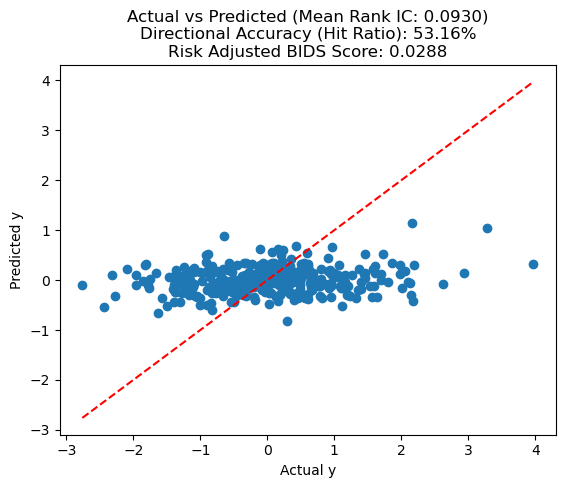

In [18]:
param_grid = {'alpha': np.logspace(-4,-1,10)}
grid = RollingGridSearch(Lasso(max_iter=1000, tol=1e-4, selection="random"), param_grid, min_train_size=12,verbose=0)
grid.fit(X_train, y_train)

print(f"Best Alpha: {grid.best_params_}")
print("Best Score:", grid.best_score_)
coefs = grid.best_model_.coef_
print(f"{np.sum(coefs != 0)} de {len(coefs)}")
non_zero_features = df[features].columns[coefs != 0]
print(non_zero_features)
coef_table = pd.DataFrame({
    'feature': df[features].columns,
    'coefficient': coefs,
    'non_zero': coefs != 0
})
print(coef_table)

model = grid.best_model_

train_months = len(X_train)

y_preds = []
y_trues = []
for t in range(train_months,len(X_val)):
    X_prev = X_val[t-1]
    X_curr = X_val[t]
    n_prev = len(X_prev)

    model.fit(X_prev, y_val[:n_prev])
    y_preds.append(model.predict(X_curr[n_prev:]))
    y_trues.append(y_val[n_prev:len(X_curr)])

ics = [spearmanr(y_pred,y_true)[0] for y_pred,y_true in zip(y_preds,y_trues)]
bids_scores = [bids(y_pred,y_true) for y_pred,y_true in zip(y_preds,y_trues)]
mu = np.mean(bids_scores)
sigma = np.std(bids_scores) + 1e-6
# Return the Risk-Adjusted BIDS, this favors high-performing models that don't fluctuate wildly month-to-month
ra_bids = mu * (mu / sigma)

y_pred = np.concatenate(y_preds)
y_true = np.concatenate(y_trues)

plt.scatter(y_true, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_true.min(), y_true.max()], [y_true.min(),y_true.max()], 'r--')
sign_accuracy = np.mean(np.sign(y_true) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (Mean Rank IC: {np.mean(ics):.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}\nRisk Adjusted BIDS Score: {ra_bids:.4f}")
plt.show()

Best Alpha: {'alpha': np.float64(1.8329807108324356)}
Best Score: 0.01383231848711109
34 de 34
Index(['Semi-annual Log Returns', 'VMA60', 'Percentage Intraday Range',
       'Average Gains', 'Average Losses', 'RS', '10-day Efficiency Ratio',
       'Body Up', 'Body Down', 'Monthly Conviction Ratio',
       'Volatility of Volatility', 'Volatility Term Structure Slope',
       'Return Autocorr 5D', 'Return Autocorr 10D',
       'Monthly Return Acceleration', 'Trend Strength',
       'Monthly Hurst Exponent', 'Gap Up', 'Gap Persistence', 'Dollar Volume',
       'Volume Weighted Return', 'Price Volume Correlation',
       'Monthly Intraday Intensity', '21 Day Beta', '63 Day Beta',
       'MA 20 Beta', 'MA 126 Beta', 'MA60 Alpha', 'Monthly Alpha Volatility',
       'Semi-annual Alpha Volatility', 'Amihud_Illiquidity',
       'Amihud_Illiquidity_21d', 'Volume_Imbalance', 'VPIN_Signal_21d'],
      dtype='str')
                            feature  coefficient  non_zero
0           Semi-annual 

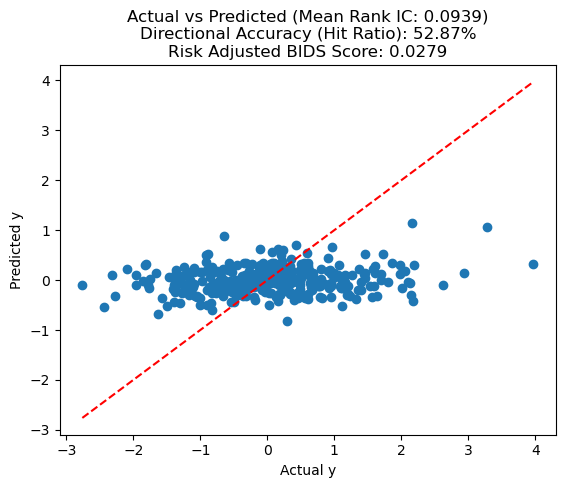

In [19]:
param_grid = {'alpha': np.logspace(-1, 5, 20)}
grid = RollingGridSearch(Ridge(max_iter=1000,tol=1e-4,solver="cholesky"), param_grid, min_train_size=12,verbose=0)

grid.fit(X_train, y_train)

print(f"Best Alpha: {grid.best_params_}")
print("Best Score:", grid.best_score_)
coefs = grid.best_model_.coef_
print(f"{np.sum(coefs != 0)} de {len(coefs)}")
non_zero_features = df[features].columns[coefs != 0]
print(non_zero_features)
coef_table = pd.DataFrame({
    'feature': df[features].columns,
    'coefficient': coefs,
    'non_zero': coefs != 0
})
print(coef_table)

model = grid.best_model_

train_months = len(X_train)

y_preds = []
y_trues = []
for t in range(train_months,len(X_val)):
    X_prev = X_val[t-1]
    X_curr = X_val[t]
    n_prev = len(X_prev)

    model.fit(X_prev, y_val[:n_prev])
    y_preds.append(model.predict(X_curr[n_prev:]))
    y_trues.append(y_val[n_prev:len(X_curr)])

ics = [spearmanr(y_pred,y_true)[0] for y_pred,y_true in zip(y_preds,y_trues)]
bids_scores = [bids(y_pred,y_true) for y_pred,y_true in zip(y_preds,y_trues)]
mu = np.mean(bids_scores)
sigma = np.std(bids_scores) + 1e-6
# Return the Risk-Adjusted BIDS, this favors high-performing models that don't fluctuate wildly month-to-month
ra_bids = mu * (mu / sigma)

y_pred = np.concatenate(y_preds)
y_true = np.concatenate(y_trues)

plt.scatter(y_true, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_true.min(), y_true.max()], [y_true.min(),y_true.max()], 'r--')
sign_accuracy = np.mean(np.sign(y_true) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (Mean Rank IC: {np.mean(ics):.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}\nRisk Adjusted BIDS Score: {ra_bids:.4f}")
plt.show()

Best Params: {'alpha': np.float64(0.000545559478116852), 'l1_ratio': np.float64(0.1)}
Best Score: 0.013446936373367854
34 de 34
Index(['Semi-annual Log Returns', 'VMA60', 'Percentage Intraday Range',
       'Average Gains', 'Average Losses', 'RS', '10-day Efficiency Ratio',
       'Body Up', 'Body Down', 'Monthly Conviction Ratio',
       'Volatility of Volatility', 'Volatility Term Structure Slope',
       'Return Autocorr 5D', 'Return Autocorr 10D',
       'Monthly Return Acceleration', 'Trend Strength',
       'Monthly Hurst Exponent', 'Gap Up', 'Gap Persistence', 'Dollar Volume',
       'Volume Weighted Return', 'Price Volume Correlation',
       'Monthly Intraday Intensity', '21 Day Beta', '63 Day Beta',
       'MA 20 Beta', 'MA 126 Beta', 'MA60 Alpha', 'Monthly Alpha Volatility',
       'Semi-annual Alpha Volatility', 'Amihud_Illiquidity',
       'Amihud_Illiquidity_21d', 'Volume_Imbalance', 'VPIN_Signal_21d'],
      dtype='str')
                            feature  coefficient  

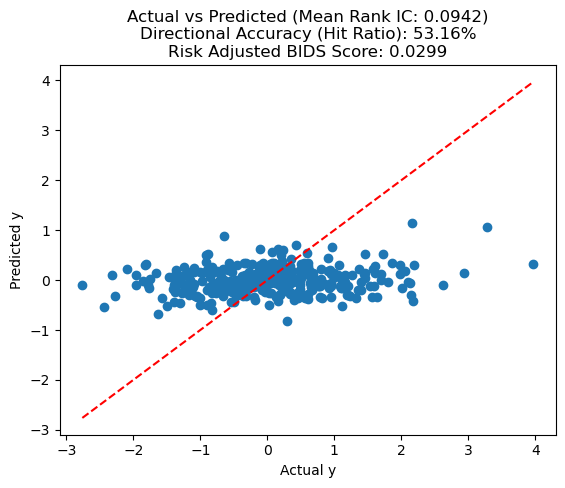

In [20]:
param_grid = {
    'alpha': np.logspace(-4,3, 20),
    'l1_ratio': np.linspace(0.1, 0.9, 9)
}
grid = RollingGridSearch(ElasticNet(max_iter=1000,tol=1e-4), param_grid, min_train_size=12,verbose=0)

grid.fit(X_train, y_train)

print(f"Best Params: {grid.best_params_}")
print("Best Score:", grid.best_score_)
coefs = grid.best_model_.coef_
print(f"{np.sum(coefs != 0)} de {len(coefs)}")
non_zero_features = df[features].columns[coefs != 0]
print(non_zero_features)
coef_table = pd.DataFrame({
    'feature': df[features].columns,
    'coefficient': coefs,
    'non_zero': coefs != 0
})
print(coef_table)

model = grid.best_model_

train_months = len(X_train)

y_preds = []
y_trues = []
for t in range(train_months,len(X_val)):
    X_prev = X_val[t-1]
    X_curr = X_val[t]
    n_prev = len(X_prev)

    model.fit(X_prev, y_val[:n_prev])
    y_preds.append(model.predict(X_curr[n_prev:]))
    y_trues.append(y_val[n_prev:len(X_curr)])

ics = [spearmanr(y_pred,y_true)[0] for y_pred,y_true in zip(y_preds,y_trues)]
bids_scores = [bids(y_pred,y_true) for y_pred,y_true in zip(y_preds,y_trues)]
mu = np.mean(bids_scores)
sigma = np.std(bids_scores) + 1e-6
# Return the Risk-Adjusted BIDS, this favors high-performing models that don't fluctuate wildly month-to-month
ra_bids = mu * (mu / sigma)

y_pred = np.concatenate(y_preds)
y_true = np.concatenate(y_trues)

plt.scatter(y_true, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_true.min(), y_true.max()], [y_true.min(),y_true.max()], 'r--')
sign_accuracy = np.mean(np.sign(y_true) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (Mean Rank IC: {np.mean(ics):.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}\nRisk Adjusted BIDS Score: {ra_bids:.4f}")
plt.show()

In [ ]:
# try one more lin model
# huber regressor is more resistant to outliers

param_grid = {
    'alpha': np.logspace(1, 5, 10),
    'epsilon': np.linspace(1.01,1.5,10)
}
grid = RollingGridSearch(HuberRegressor(max_iter=1000,tol=1e-4), param_grid, min_train_size=12,verbose=0)
grid.fit(X_train, y_train)

print(f"Best Params: {grid.best_params_}")
print("Best Score:", grid.best_score_)
coefs = grid.best_model_.coef_
print(f"{np.sum(coefs != 0)} de {len(coefs)}")
non_zero_features = df[features].columns[coefs != 0]
print(non_zero_features)
coef_table = pd.DataFrame({
    'feature': df[features].columns,
    'coefficient': coefs,
    'non_zero': coefs != 0
})
print(coef_table)

model = grid.best_model_

train_months = len(X_train)

y_preds = []
y_trues = []
for t in range(train_months,len(X_val)):
    X_prev = X_val[t-1]
    X_curr = X_val[t]
    n_prev = len(X_prev)

    model.fit(X_prev, y_val[:n_prev])
    y_preds.append(model.predict(X_curr[n_prev:]))
    y_trues.append(y_val[n_prev:len(X_curr)])

ics = [spearmanr(y_pred,y_true)[0] for y_pred,y_true in zip(y_preds,y_trues)]
bids_scores = [bids(y_pred,y_true) for y_pred,y_true in zip(y_preds,y_trues)]
mu = np.mean(bids_scores)
sigma = np.std(bids_scores) + 1e-6
# Return the Risk-Adjusted BIDS, this favors high-performing models that don't fluctuate wildly month-to-month
ra_bids = mu * (mu / sigma)

y_pred = np.concatenate(y_preds)
y_true = np.concatenate(y_trues)

plt.scatter(y_true, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_true.min(), y_true.max()], [y_true.min(),y_true.max()], 'r--')
sign_accuracy = np.mean(np.sign(y_true) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (Mean Rank IC: {np.mean(ics):.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}\nRisk Adjusted BIDS Score: {ra_bids:.4f}")
plt.show()

In [ ]:
# build optuna hpt search
#bayesian optimizer, not brute force grid search which for larger more complex models would be unfeasible


class RollingOptunaSearch():

    def __init__(self, model_builder, min_train_size=24, n_trials=30, parallel_windows=0,sampler=None, pruner=None, verbose=1):
        self.model_builder = model_builder
        self.scorer_ = bids
        self.min_train_size = min_train_size
        self.n_trials = n_trials
        self.parallel_windows = parallel_windows
        self.verbose = verbose
        self.sampler = sampler or optuna.samplers.TPESampler(multivariate=True, seed=42)
        self.pruner = pruner or optuna.pruners.MedianPruner(n_startup_trials=15, n_warmup_steps=5, interval_steps=1)

    def _build_objective(self, X, y, lens):

        scorer = self.scorer_

        def objective(trial):
            model_base = self.model_builder(trial)
            
            # --- MODE A: WINDOW-LEVEL PARALLELISM ---
            if self.parallel_windows:
                model_template = self.model_builder(optuna.trial.FixedTrial(trial.params))
                def evaluate_window(train_len, t):
                    if len(X[t]) <= train_len: 
                        return None
                    model_step = clone(model_template)
                    model_step.fit(X[t][:train_len], y[:train_len])
                    y_pred = model_step.predict(X[t][train_len:])
                    return scorer(y_pred, y[train_len:len(X[t])])

                scores = Parallel(n_jobs=self.n_jobs, prefer="threads")(
                    delayed(evaluate_window)(tl, t) for tl, t in lens
                )

                scores = [s for s in scores if s is not None]

                mu = np.mean(scores)
                sigma = np.std(scores) + 1e-6
    
                # Return the Risk-Adjusted BIDS, this favors high-performing models that don't fluctuate wildly month-to-month
                return mu * (mu / sigma)

            # --- MODE B: SEQUENTIAL WITH PRUNING ---
            else:
                scores = []
                for i, (train_len, t) in enumerate(lens):
                    if len(X[t]) <= train_len: 
                        continue

                    model_base.fit(X[t][:train_len], y[:train_len])
                    y_pred = model_base.predict(X[t][train_len:])
                    score = scorer(y_pred, y[train_len:len(X[t])])
                    scores.append(score)

                    current_mean = np.mean(scores)
                    trial.report(current_mean, step=i)
                    if trial.should_prune():
                        raise optuna.exceptions.TrialPruned()
                
                mu = np.mean(scores)
                sigma = np.std(scores) + 1e-6
    
                # Return the Risk-Adjusted BIDS, this favors high-performing models that don't fluctuate wildly month-to-month
                return mu * (mu / sigma)
        return objective

    def fit(self, X, y):

        start_t = max(1, self.min_train_size)
        lens = [(len(X[t-1]), t) for t in range(start_t, len(X))]

        study = optuna.create_study(
            direction="maximize",
            sampler=self.sampler,
            pruner=self.pruner
        )

        optuna_jobs = 1 if self.parallel_windows else -1

        study.optimize(self._build_objective(X, y, lens), n_trials=self.n_trials,n_jobs=optuna_jobs)

        self.study_ = study
        self.best_params_ = study.best_params
        self.best_score_ = study.best_value

        if self.verbose:
            print("Best params:", self.best_params_)
            print("Best score:", self.best_score_)

        self.best_model_ = self.model_builder(optuna.trial.FixedTrial(self.best_params_))
        self.best_model_.fit(X[-1], y)

        return self

    def predict(self, X):
        return self.best_model_.predict(X)    

/home/jaime/anaconda3/envs/TFG/lib/python3.11/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-05-14 10:29:20,656] A new study created in memory with name: no-name-29313cf0-cb0e-42dd-82dc-9bcf2f1b5e67


[I 2026-05-14 10:30:31,758] Trial 14 finished with value: 0.005866950868631418 and parameters: {'n_estimators': 81, 'max_depth': 11, 'max_features': 0.7234010554457615, 'min_samples_leaf': 17, 'min_samples_split': 12}. Best is trial 14 with value: 0.005866950868631418.
[I 2026-05-14 10:30:49,332] Trial 11 finished with value: 0.002440114615826453 and parameters: {'n_estimators': 113, 'max_depth': 4, 'max_features': 0.823585867731981, 'min_samples_leaf': 18, 'min_samples_split': 9}. Best is trial 14 with value: 0.005866950868631418.
[I 2026-05-14 10:31:17,439] Trial 6 finished with value: 0.006249788997259285 and parameters: {'n_estimators': 142, 'max_depth': 9, 'max_features': 0.5781724438878684, 'min_samples_leaf': 10, 'min_samples_split': 5}. Best is trial 6 with value: 0.006249788997259285.
[I 2026-05-14 10:31:29,621] Trial 1 finished with value: 0.0036813660938546616 and parameters: {'n_estimators': 165, 'max_depth': 12, 'max_features': 0.4084604896590571, 'min_samples_leaf': 7, 'm

Best Params: {'n_estimators': 149, 'max_depth': 11, 'max_features': 0.7037409643889687, 'min_samples_leaf': 15, 'min_samples_split': 9}
Best Score: 0.011416082685939745
34 de 34
Index(['Semi-annual Log Returns', 'VMA60', 'Percentage Intraday Range',
       'Average Gains', 'Average Losses', 'RS', '10-day Efficiency Ratio',
       'Body Up', 'Body Down', 'Monthly Conviction Ratio',
       'Volatility of Volatility', 'Volatility Term Structure Slope',
       'Return Autocorr 5D', 'Return Autocorr 10D',
       'Monthly Return Acceleration', 'Trend Strength',
       'Monthly Hurst Exponent', 'Gap Up', 'Gap Persistence', 'Dollar Volume',
       'Volume Weighted Return', 'Price Volume Correlation',
       'Monthly Intraday Intensity', '21 Day Beta', '63 Day Beta',
       'MA 20 Beta', 'MA 126 Beta', 'MA60 Alpha', 'Monthly Alpha Volatility',
       'Semi-annual Alpha Volatility', 'Amihud_Illiquidity',
       'Amihud_Illiquidity_21d', 'Volume_Imbalance', 'VPIN_Signal_21d'],
      dtype='str')


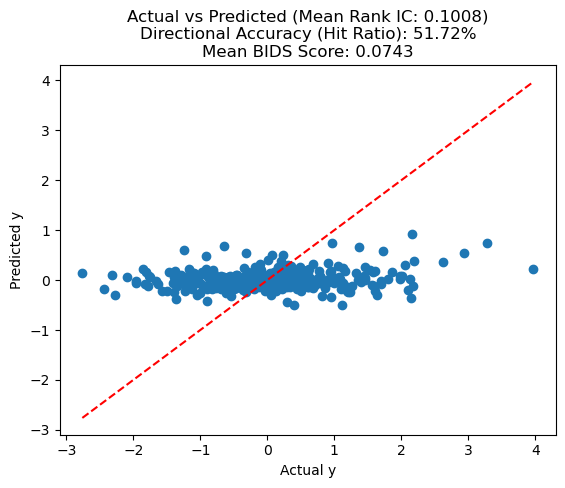

In [ ]:
#random forest

def rf_builder(trial):
    return RandomForestRegressor(
        n_estimators=trial.suggest_int("n_estimators", 80, 300),
        max_depth=trial.suggest_int("max_depth", 4, 14),
        max_features=trial.suggest_float("max_features", 0.3, 1.0),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 4, 18),
        min_samples_split=trial.suggest_int("min_samples_split", 3, 12),
        n_jobs=1,
        random_state=42
    )

grid = RollingOptunaSearch(
    rf_builder,
    min_train_size=12,
    n_trials=300,
    pruner=optuna.pruners.MedianPruner(n_startup_trials=8, n_warmup_steps=3),
    verbose=0
)

grid.fit(X_train, y_train)

random_forest_model = grid.best_model_

print(f"Best Params: {grid.best_params_}")
print("Best Score:", grid.best_score_)
importances = grid.best_model_.feature_importances_
print(f"{np.sum(importances != 0)} de {len(importances)}")
feature_names = df[features].columns
non_zero_features = feature_names[importances != 0]
print(non_zero_features)
importance_table = pd.DataFrame({
    'feature': feature_names,
    'importance': importances,
    'non_zero': importances != 0
})
print(importance_table.sort_values('importance', ascending=False))

model = random_forest_model

train_months = len(X_train)

y_preds = []
y_trues = []
for t in range(train_months,len(X_val)):
    X_prev = X_val[t-1]
    X_curr = X_val[t]
    n_prev = len(X_prev)

    model.fit(X_prev, y_val[:n_prev])
    y_preds.append(model.predict(X_curr[n_prev:]))
    y_trues.append(y_val[n_prev:len(X_curr)])

ics = [spearmanr(y_pred,y_true)[0] for y_pred,y_true in zip(y_preds,y_trues)]
bids_scores = [bids(y_pred,y_true) for y_pred,y_true in zip(y_preds,y_trues)]
mu = np.mean(bids_scores)
sigma = np.std(bids_scores) + 1e-6
# Return the Risk-Adjusted BIDS, this favors high-performing models that don't fluctuate wildly month-to-month
ra_bids = mu * (mu / sigma)

y_pred = np.concatenate(y_preds)
y_true = np.concatenate(y_trues)

plt.scatter(y_true, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_true.min(), y_true.max()], [y_true.min(),y_true.max()], 'r--')
sign_accuracy = np.mean(np.sign(y_true) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (Mean Rank IC: {np.mean(ics):.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}\nRisk Adjusted BIDS Score: {ra_bids:.4f}")
plt.show()

In [ ]:
# XGBoost

def xg_builder(trial):
    return XGBRegressor(
        n_estimators=trial.suggest_int("n_estimators", 700, 1500),
        max_depth=trial.suggest_int("max_depth", 8, 12),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.06, log=True),
        min_child_weight=trial.suggest_float("min_child_weight", 0.3, 3.0, log=True),
        gamma=trial.suggest_float("gamma", 0.0, 0.2),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-6, 0.1, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1.0, 6.0, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 0.8),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.85, 1.0),
        n_jobs=1,
        random_state=42
    )

grid = RollingOptunaSearch(
    xg_builder,
    min_train_size=12,
    n_trials=350,
    pruner=optuna.pruners.SuccessiveHalvingPruner(min_resource=1, reduction_factor=3),
    sampler=optuna.samplers.TPESampler(seed=42),
    verbose=0
)

grid.fit(X_train, y_train)
xgboost_model = grid.best_model_

print(f"Best Params: {grid.best_params_}")
print("Best Score:", grid.best_score_)
importances = grid.best_model_.feature_importances_
print(f"{np.sum(importances != 0)} de {len(importances)}")
feature_names = df[features].columns
non_zero_features = feature_names[importances != 0]
print(non_zero_features)
importance_table = pd.DataFrame({
    'feature': feature_names,
    'importance': importances,
    'non_zero': importances != 0
})
print(importance_table.sort_values('importance', ascending=False))

model = xgboost_model

train_months = len(X_train)

y_preds = []
y_trues = []
for t in range(train_months,len(X_val)):
    X_prev = X_val[t-1]
    X_curr = X_val[t]
    n_prev = len(X_prev)

    model.fit(X_prev, y_val[:n_prev])
    y_preds.append(model.predict(X_curr[n_prev:]))
    y_trues.append(y_val[n_prev:len(X_curr)])

ics = [spearmanr(y_pred,y_true)[0] for y_pred,y_true in zip(y_preds,y_trues)]
bids_scores = [bids(y_pred,y_true) for y_pred,y_true in zip(y_preds,y_trues)]
mu = np.mean(bids_scores)
sigma = np.std(bids_scores) + 1e-6
# Return the Risk-Adjusted BIDS, this favors high-performing models that don't fluctuate wildly month-to-month
ra_bids = mu * (mu / sigma)

y_pred = np.concatenate(y_preds)
y_true = np.concatenate(y_trues)

plt.scatter(y_true, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_true.min(), y_true.max()], [y_true.min(),y_true.max()], 'r--')
sign_accuracy = np.mean(np.sign(y_true) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (Mean Rank IC: {np.mean(ics):.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}\nRisk Adjusted BIDS Score: {ra_bids:.4f}")
plt.show()

[I 2026-05-14 10:39:50,422] A new study created in memory with name: no-name-770905fb-8d96-49da-8fe3-bc35dd92b25d
[I 2026-05-14 10:39:55,595] Trial 17 pruned. 
[I 2026-05-14 10:39:55,822] Trial 5 pruned. 
[I 2026-05-14 10:39:56,290] Trial 3 pruned. 
[I 2026-05-14 10:39:56,919] Trial 4 pruned. 
[I 2026-05-14 10:39:56,928] Trial 2 pruned. 
[I 2026-05-14 10:39:56,929] Trial 13 pruned. 
[I 2026-05-14 10:39:57,063] Trial 12 pruned. 
[I 2026-05-14 10:39:57,447] Trial 7 pruned. 
[I 2026-05-14 10:39:57,679] Trial 10 pruned. 
[I 2026-05-14 10:39:58,835] Trial 14 pruned. 
[I 2026-05-14 10:39:58,994] Trial 18 pruned. 
[I 2026-05-14 10:39:59,248] Trial 1 pruned. 
[I 2026-05-14 10:39:59,837] Trial 9 pruned. 
[I 2026-05-14 10:40:02,610] Trial 22 pruned. 
[I 2026-05-14 10:40:02,632] Trial 20 pruned. 
[I 2026-05-14 10:40:02,877] Trial 25 pruned. 
[I 2026-05-14 10:40:04,082] Trial 16 pruned. 
[I 2026-05-14 10:40:04,737] Trial 27 pruned. 
[I 2026-05-14 10:40:06,397] Trial 26 pruned. 
[I 2026-05-14 10:40

[I 2026-05-13 21:06:29,503] Trial 35 finished with value: 0.016163921789136997 and parameters: {'hidden_layer_sizes': '(32, 16)', 'alpha': 2.3183603757692963, 'learning_rate_init': 0.0042784195145164445, 'learning_rate': 'constant', 'batch_size': 512, 'activation': 'relu'}. Best is trial 4 with value: 0.017820057043912478.
/home/jaime/anaconda3/envs/TFG/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


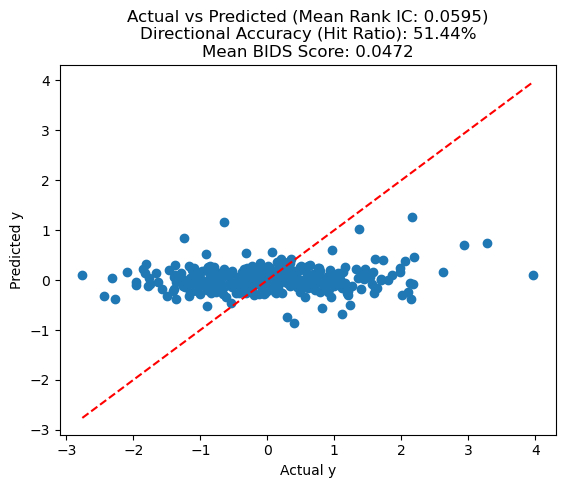

In [ ]:
# test out averaging of random forest and xgboost

train_months = len(X_train)

y_preds = []
y_trues = []
for t in range(train_months,len(X_val)):
    X_prev = X_val[t-1]
    X_curr = X_val[t]
    n_prev = len(X_prev)

    random_forest_model.fit(X_prev, y_val[:n_prev])
    xgboost_model.fit(X_prev, y_val[:n_prev])
    y_preds.append((random_forest_model.predict(X_curr[n_prev:]) + xgboost_model.predict(X_curr[n_prev:])) / 2)
    y_trues.append(y_val[n_prev:len(X_curr)])

ics = [spearmanr(y_pred,y_true)[0] for y_pred,y_true in zip(y_preds,y_trues)]
bids_scores = [bids(y_pred,y_true) for y_pred,y_true in zip(y_preds,y_trues)]
mu = np.mean(bids_scores)
sigma = np.std(bids_scores) + 1e-6
# Return the Risk-Adjusted BIDS, this favors high-performing models that don't fluctuate wildly month-to-month
ra_bids = mu * (mu / sigma)

y_pred = np.concatenate(y_preds)
y_true = np.concatenate(y_trues)

plt.scatter(y_true, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_true.min(), y_true.max()], [y_true.min(),y_true.max()], 'r--')
sign_accuracy = np.mean(np.sign(y_true) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (Mean Rank IC: {np.mean(ics):.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}\nRisk Adjusted BIDS Score: {ra_bids:.4f}")
plt.show()

In [ ]:
# MLP

def mlp_builder(trial):
    hidden = trial.suggest_categorical("hidden_layer_sizes", ["(16,)","(32,)","(64,)", "(128,)", "(256,)",
                                                          "(32, 16)","(64, 32)","(128, 64)","(256, 128)",
                                                          "(128, 64, 32)","(256, 128, 64)","(64, 64)"])

    return MLPRegressor(
        hidden_layer_sizes=literal_eval(hidden),
        alpha=trial.suggest_float("alpha", 0.1, 10.0, log=True),
        learning_rate_init=trial.suggest_float("learning_rate_init", 5e-5, 5e-3, log=True),
        learning_rate=trial.suggest_categorical("learning_rate", ['constant', 'adaptive']),
        batch_size=trial.suggest_categorical("batch_size", [64, 128, 256]),
        activation=trial.suggest_categorical("activation", ['relu', 'tanh']),
        max_iter=trial.suggest_int("max_iter", 600, 1200),
        solver='adam',
        early_stopping=False,
        random_state=42
    )

grid = RollingOptunaSearch(
    mlp_builder,
    min_train_size=12,
    n_trials=150,
    pruner=optuna.pruners.SuccessiveHalvingPruner(min_resource=1, reduction_factor=3),
    sampler=optuna.samplers.TPESampler(multivariate=True, seed=42),
    verbose=0
)

grid.fit(X_train, y_train)
print(f"Best Params: {grid.best_params_}")
print("Best Score:", grid.best_score_)

model = grid.best_model_

train_months = len(X_train)

y_preds = []
y_trues = []
for t in range(train_months,len(X_val)):
    X_prev = X_val[t-1]
    X_curr = X_val[t]
    n_prev = len(X_prev)

    model.fit(X_prev, y_val[:n_prev])
    y_preds.append(model.predict(X_curr[n_prev:]))
    y_trues.append(y_val[n_prev:len(X_curr)])

ics = [spearmanr(y_pred,y_true)[0] for y_pred,y_true in zip(y_preds,y_trues)]
bids_scores = [bids(y_pred,y_true) for y_pred,y_true in zip(y_preds,y_trues)]
mu = np.mean(bids_scores)
sigma = np.std(bids_scores) + 1e-6
# Return the Risk-Adjusted BIDS, this favors high-performing models that don't fluctuate wildly month-to-month
ra_bids = mu * (mu / sigma)

y_pred = np.concatenate(y_preds)
y_true = np.concatenate(y_trues)

plt.scatter(y_true, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_true.min(), y_true.max()], [y_true.min(),y_true.max()], 'r--')
sign_accuracy = np.mean(np.sign(y_true) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (Mean Rank IC: {np.mean(ics):.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}\nRisk Adjusted BIDS Score: {ra_bids:.4f}")
plt.show()

/home/jaime/anaconda3/envs/TFG/lib/python3.11/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-05-13 21:07:33,756] A new study created in memory with name: no-name-47af927b-7cac-4501-b030-aa1c220fa662
/home/jaime/anaconda3/envs/TFG/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (887) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/jaime/anaconda3/envs/TFG/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (849) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/jaime/anaconda3/envs/TFG/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

In [26]:
# try out simple mlp but with pytorch for gpu accelaration

class MLP(nn.Module):

    def __init__(self,input_size,hidden_layers,activation,lr,wd,dropout,batch_size):
        super().__init__()
        self.lr = lr
        self.wd = wd
        self.batch_size = batch_size
        layers = []
        in_features = input_size
        activation_map = {
            "relu": nn.ReLU,
            "tanh": nn.Tanh,
            "leaky_relu": nn.LeakyReLU,
            "elu": nn.ELU
        }
        self.activation = activation
        
        use_dropout = dropout > 0

        for i,h in enumerate(hidden_layers):

            lin = nn.Linear(in_features,h)

            if activation == "relu":
                nn.init.kaiming_uniform_(lin.weight, nonlinearity='relu')
            elif activation == "leaky_relu":
                nn.init.kaiming_uniform_(lin.weight, nonlinearity='leaky_relu')
            else:
                nn.init.xavier_uniform_(lin.weight)
            nn.init.zeros_(lin.bias)

            layers.append(lin)
            layers.append(activation_map[activation]())

            if use_dropout and i < len(hidden_layers) - 1:
                layers.append(nn.Dropout(dropout))

            in_features = h
        
        lin = nn.Linear(in_features,1)
        nn.init.xavier_uniform_(lin.weight)
        nn.init.zeros_(lin.bias)
        layers.append(lin)

        self.model = nn.Sequential(*layers)

    def forward(self,x):
        return self.model(x).squeeze(-1)

In [ ]:
# pytorch version of bids
def bids_torch(y_true, y_pred):
    def _rankdata_avg(x):
        x = x.contiguous().view(-1).to(dtype=torch.float64)
        n = x.size(0)
        vals, idx = torch.sort(x)
        _, counts = torch.unique_consecutive(vals, return_counts=True)
        counts = counts.to(device=vals.device)
        cumsum = torch.cumsum(counts, dim=0)
        starts = torch.cat((torch.tensor([0], device=vals.device, dtype=cumsum.dtype), cumsum[:-1]))
        ends = starts + counts - 1
        avg_ranks = (starts.to(dtype=torch.float64) + ends.to(dtype=torch.float64) + 2.0) / 2.0
        ranks_sorted = torch.repeat_interleave(avg_ranks, counts)
        ranks = torch.empty(n, dtype=torch.float64, device=vals.device)
        ranks[idx] = ranks_sorted
        return ranks

    t_rank = _rankdata_avg(y_true)
    p_rank = _rankdata_avg(y_pred)

    t_rank_c = t_rank - t_rank.mean()
    p_rank_c = p_rank - p_rank.mean()

    denom = t_rank_c.std(unbiased=False) * p_rank_c.std(unbiased=False)
    rank_ic = (t_rank_c * p_rank_c).mean() / denom

    if torch.isnan(rank_ic):
        rank_ic = torch.tensor(0.0, dtype=torch.float64, device=rank_ic.device)

    da_centered = 2 * ((torch.sign(y_true) == torch.sign(y_pred)).float().mean() - 0.5)
    da_centered = da_centered.to(dtype=torch.float64)

    return 0.6 * rank_ic + 0.4 * da_centered

In [28]:
def train_model(model,dataloaders,optimizer,criterion,epochs,verbose=0):
    if verbose:
        run_train_loss, run_val_loss, run_bids_score = [], [], []

    ema_bids = None
    max_bids = -np.inf
    alpha = 0.9

    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=epochs,)

    for e in range(epochs):
        model.train()
        train_loss = 0
        for batch_x, batch_y in dataloaders["train"]:

            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(batch_x),batch_y)
            loss.backward()
            optimizer.step()

            if verbose:
                train_loss += loss.item() * batch_y.size(0)               
        
        if "val" in dataloaders:
            model.eval()
            with torch.no_grad():

                preds = torch.cat([model(batch_x) for batch_x, _ in dataloaders["val"]])
                targets = torch.cat([batch_y for _, batch_y in dataloaders["val"]])

                current_bids = bids_torch(targets, preds).item()
                ema_bids = current_bids if ema_bids is None else (alpha * ema_bids) + ((1 - alpha) * current_bids)

                if ema_bids > max_bids:
                    max_bids = ema_bids
        
        scheduler.step()     
        
        if verbose:
            train_loss /= len(dataloaders["train"].dataset)  
            print(f"Epoch {e+1}/{epochs}.. ")
            print(f"Train loss: {train_loss:.6f}.. ")
            if "val" in dataloaders:
                val_loss = criterion(preds,targets).item()
                print(f"Validation Loss: {val_loss}")
                print(f"BIDS Score: {ema_bids}")
        
            run_train_loss.append(train_loss)
            if "val" in dataloaders:
                run_val_loss.append(val_loss)
                run_bids_score.append(ema_bids)
            
    
    if verbose:
        epochs_range = range(1, e+2)
        plt.plot(epochs_range, run_train_loss, label='Train Loss')
        if "val" in dataloaders:
            plt.plot(epochs_range,run_val_loss, label="Validation Loss")
            plt.plot(epochs_range,run_bids_score, label="BIDS EMA Score")
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.title('Loss')
        plt.show()

    
    return max_bids if "val" in dataloaders else model

In [29]:
def reset_weights(model, activation_type):

    for m in model.modules():
        if isinstance(m, (nn.Linear, nn.Conv1d, nn.Conv2d)):
            if activation_type in ["relu", "leaky_relu"]:
                nn.init.kaiming_uniform_(m.weight, nonlinearity=activation_type)
            else:
                nn.init.xavier_uniform_(m.weight)
            
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        
        elif isinstance(m, (nn.RNN, nn.LSTM, nn.GRU)):
            for name, param in m.named_parameters():
                if 'weight' in name:
                    nn.init.orthogonal_(param)
                elif 'bias' in name:
                    nn.init.zeros_(param)

In [ ]:
# create optuna search for pytorch

class RollingOptunaSearchPyTorch():

    def __init__(self, model_builder,device,min_train_size=24, n_trials=30, sampler=None, pruner=None, verbose=1):
        self.model_builder = model_builder
        self.device = device
        self.min_train_size = min_train_size
        self.n_trials = n_trials
        self.verbose = verbose
        self.sampler = sampler or optuna.samplers.TPESampler(multivariate=True, seed=42)
        self.pruner = pruner or optuna.pruners.MedianPruner(n_startup_trials=15, n_warmup_steps=5, interval_steps=1)

    def _build_objective(self, Xs, y, lens):


        def objective(trial):

            model = self.model_builder(trial).to(self.device)
            scores = []

            for i, (train_len,t) in enumerate(lens):

                if len(Xs[t]) <= train_len:
                    continue

                train_dataloader = DataLoader(TensorDataset(Xs[t][:train_len], y[:train_len]),batch_size=model.batch_size,shuffle=False)
                val_dataloader = DataLoader(TensorDataset(Xs[t][train_len:], y[train_len:len(Xs[t])]),batch_size=model.batch_size,shuffle=False)

                reset_weights(model,model.activation)

                score = train_model(model, {"train" : train_dataloader, "val" : val_dataloader},optim.AdamW(model.parameters(),lr=model.lr,weight_decay=model.wd),nn.MSELoss(),130,0)
                scores.append(score)

                current_mean = np.mean(scores)

                trial.report(current_mean, step=i)
                if trial.should_prune():
                    raise optuna.exceptions.TrialPruned()
            
            mu = np.mean(scores)
            sigma = np.std(scores) + 1e-6

            # Check if mu is negative; if so, return mu to help Optuna move away from it
            # Otherwise, return the risk-adjusted score
            return mu * (mu / sigma) if mu > 0 else mu
        
        return objective

    def fit(self, X, y):

        start_t = max(1, self.min_train_size)
        lens = [(len(X[t-1]), t) for t in range(start_t, len(X))]

        study = optuna.create_study(
            direction="maximize",
            sampler=self.sampler,
            pruner=self.pruner
        )

        study.optimize(self._build_objective(X, y, lens), n_trials=self.n_trials)

        self.study_ = study
        self.best_params_ = study.best_params
        self.best_score_ = study.best_value

        if self.verbose:
            print("Best params:", self.best_params_)
            print("Best score:", self.best_score_)

        self.best_model_ = self.model_builder(optuna.trial.FixedTrial(self.best_params_)).to(self.device)
        train_dataloader = DataLoader(TensorDataset(X[-1],y),batch_size=self.best_model_.batch_size,shuffle=False)
        self.best_model_ = train_model(self.best_model_,{"train": train_dataloader},optim.AdamW(self.best_model_.parameters(),lr=self.best_model_.lr,weight_decay=self.best_model_.wd),nn.MSELoss(),200,1)

        return self

    def predict(self, X):
        self.best_model_.eval()
        with torch.no_grad():
            return self.best_model_(X).cpu().numpy()   

In [ ]:
# for hpt only
dataset = HPTDataset()
X_train, y_train = dataset.get("2015-12-31")
X_train = [np.ascontiguousarray(x) for x in X_train]
y_train = np.ascontiguousarray(y_train)
X_val, y_val = dataset.get("2016-12-31")
X_val = [np.ascontiguousarray(x) for x in X_val]
y_val = np.ascontiguousarray(y_val)

In [ ]:
torch.set_float32_matmul_precision('high')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_train = [torch.from_numpy(x).float().to(device, non_blocking=True) for x in X_train]
y_train = torch.from_numpy(y_train).float().to(device, non_blocking=True)
X_test = [torch.from_numpy(x).float().to(device, non_blocking=True) for x in X_val]
y_test = torch.from_numpy(y_val).float().to(device, non_blocking=True)
input_features = X_train[0].shape[1]

def mlp_pytorch_builder(trial):
    hidden = trial.suggest_categorical("hidden_layer_sizes", ["[32]","[64]", "[128]",
                                                              "[32, 16]","[64, 32]","[128, 64]",
                                                              "[128, 64, 32]", "[64,64,64]"])
    return MLP(
        input_size=input_features,
        hidden_layers = literal_eval(hidden),
        activation = trial.suggest_categorical("activation", ['relu', 'tanh']),
        lr=trial.suggest_float("lr", 1e-4, 1e-2, log=True),
        wd=trial.suggest_float("wd", 1e-5, 1e-1, log=True),
        dropout = trial.suggest_float("dropout", 0.0, 0.5,step=0.05),
        batch_size=trial.suggest_categorical("batch_size", [32, 64, 128, 256, 512, len(X_train[-1])]))

grid = RollingOptunaSearchPyTorch(mlp_pytorch_builder, device,min_train_size=12, n_trials=200, verbose=0)
grid.fit(X_train, y_train)

print(f"Best Params: {grid.best_params_}")
print("Best Score:", grid.best_score_)
model = grid.best_model_

train_months = len(X_train)

y_preds = []
y_trues = []
for t in range(train_months,len(X_test)):
    X_prev = X_test[t-1]
    X_curr = X_test[t]
    n_prev = len(X_prev)
    reset_weights(model,model.activation)
    train_dataloader = DataLoader(TensorDataset(X_prev,y_test[:n_prev]),batch_size=model.batch_size,shuffle=False)
    model = train_model(model,{"train": train_dataloader},optim.AdamW(model.parameters(),lr=model.lr,weight_decay=model.wd),nn.MSELoss(),200,0)

    y_preds.append(model(X_curr[n_prev:]).cpu().numpy())
    y_trues.append(y_test[n_prev:len(X_curr)].cpu().numpy())

ics = [spearmanr(y_pred,y_true)[0] for y_pred,y_true in zip(y_preds,y_trues)]
bids_scores = [bids(y_pred,y_true) for y_pred,y_true in zip(y_preds,y_trues)]

y_pred = torch.cat(y_preds)
y_true = torch.cat(y_trues)

plt.scatter(y_true.detach().cpu().numpy(), y_pred.detach().cpu().numpy())
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_true.detach().cpu().numpy().min(), y_true.detach().cpu().numpy().max()], [y_true.detach().cpu().numpy().min(),y_true.detach().cpu().numpy().max()], 'r--')
sign_accuracy = np.mean(np.sign(y_true) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (Mean Rank IC: {np.mean(ics):.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}\nMean BIDS Score: {np.mean(bids_scores):.4f}")
plt.show()

/home/jaime/anaconda3/envs/TFG/lib/python3.11/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-05-08 14:28:05,056] A new study created in memory with name: no-name-c1b07397-154e-4d45-915a-dda3b514b76d
[I 2026-05-08 14:29:04,037] Trial 0 finished with value: 0.046745471320221804 and parameters: {'hidden_layer_sizes': '[64]', 'activation': 'tanh', 'lr': 0.00010994335574766199, 'wd': 0.07579479953348005, 'dropout': 0.45, 'batch_size': 512}. Best is trial 0 with value: 0.046745471320221804.
[I 2026-05-08 14:30:59,226] Trial 1 finished with value: 0.14445037490354215 and parameters: {'hidden_layer_sizes': '[128, 64, 32]', 'activation': 'tanh', 'lr': 0.0001238513729886094, 'wd': 0.0026926469100861782, 'dropout': 0.05, 'batch_size': 128}. Best is trial 1 with value: 0.14445037490354215.
[I 2026-05-08 14:33:50,801] Trial 2 finished with value: 0.18350968467644682 a

KeyboardInterrupt: 

In [ ]:
# now move onto final two models, CNN, RNN
# CNN first

def CNN(nn.Module):

    def __init__(self, input_features):
        super.__init__()


    def forward(self,x):
        return self.model(x).squeeze(-1)


In [ ]:
def cnn_builder(trial):
    hidden = trial.suggest_categorical("hidden_layer_sizes", ["[64]", "[128]",
                                                              "[256]", "[64, 32]",
                                                              "[128, 64]","[256, 128]",
                                                              "[128, 64, 32]", "[256, 128, 64]",
                                                              "[256, 128, 32]", "[256, 128, 64, 32]"])
    return CNN(
        input_size=input_features,
        hidden_layers = literal_eval(hidden),
        activation = trial.suggest_categorical("activation", ['relu', 'tanh']),
        lr=trial.suggest_float("lr", 1e-4, 1e-2, log=True),
        wd=trial.suggest_float("wd", 1e-6, 1e-2, log=True),
        dropout = trial.suggest_float("dropout", 0.0, 0.3,step=0.05),
        batch_size=trial.suggest_categorical("batch_size", [32, 64, 128, 256, 512, len(X_cache_t[-1])]))

grid = RollingOptunaSearchPyTorch(cnn_builder, device,min_train_size=12, n_trials=200, verbose=0)


grid.fit(X_cache_t, y_cache_t)

print(f"Best Params: {grid.best_params_}")
print("Best Score:", grid.best_score_)

y_pred = grid.predict(X_cache_t[-1])

y_cache_t = y_cache_t.to("cpu")
plt.scatter(y_cache, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_cache.min(), y_cache.max()], [y_cache.min(), y_cache.max()], 'r--')
r2 = r2_score(y_cache, y_pred)
sign_accuracy = np.mean(np.sign(y_cache) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (R^2: {r2:.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}")
plt.show()

In [ ]:
# finally, RNN

def LSTM(nn.Module):

    def __init__(self, input_features):
        super.__init__()


    def forward(self,x):
        return self.model(x).squeeze(-1)


In [ ]:
def lstm_builder(trial):
    hidden = trial.suggest_categorical("hidden_layer_sizes", ["[64]", "[128]",
                                                              "[256]", "[64, 32]",
                                                              "[128, 64]","[256, 128]",
                                                              "[128, 64, 32]", "[256, 128, 64]",
                                                              "[256, 128, 32]", "[256, 128, 64, 32]"])
    return LSTM(
        input_size=input_features,
        hidden_layers = literal_eval(hidden),
        activation = trial.suggest_categorical("activation", ['relu', 'tanh']),
        lr=trial.suggest_float("lr", 1e-4, 1e-2, log=True),
        wd=trial.suggest_float("wd", 1e-6, 1e-2, log=True),
        dropout = trial.suggest_float("dropout", 0.0, 0.3,step=0.05),
        batch_size=trial.suggest_categorical("batch_size", [32, 64, 128, 256, 512, len(X_cache_t[-1])]))

grid = RollingOptunaSearchPyTorch(lstm_builder, device,min_train_size=12, n_trials=200, verbose=0)


grid.fit(X_cache_t, y_cache_t)

print(f"Best Params: {grid.best_params_}")
print("Best Score:", grid.best_score_)

y_pred = grid.predict(X_cache_t[-1])

y_cache_t = y_cache_t.to("cpu")
plt.scatter(y_cache, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_cache.min(), y_cache.max()], [y_cache.min(), y_cache.max()], 'r--')
r2 = r2_score(y_cache, y_pred)
sign_accuracy = np.mean(np.sign(y_cache) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (R^2: {r2:.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}")
plt.show()

In [ ]:
#try a mix of cnn and lstm

def CNN_LSTM(nn.Module):

    def __init__(self, input_features):
        super.__init__()


    def forward(self,x):
        return self.model(x).squeeze(-1)

In [ ]:
def cnn_lstm_builder(trial):
    hidden = trial.suggest_categorical("hidden_layer_sizes", ["[64]", "[128]",
                                                              "[256]", "[64, 32]",
                                                              "[128, 64]","[256, 128]",
                                                              "[128, 64, 32]", "[256, 128, 64]",
                                                              "[256, 128, 32]", "[256, 128, 64, 32]"])
    return CNN_LSTM(
        input_size=input_features,
        hidden_layers = literal_eval(hidden),
        activation = trial.suggest_categorical("activation", ['relu', 'tanh']),
        lr=trial.suggest_float("lr", 1e-4, 1e-2, log=True),
        wd=trial.suggest_float("wd", 1e-6, 1e-2, log=True),
        dropout = trial.suggest_float("dropout", 0.0, 0.3,step=0.05),
        batch_size=trial.suggest_categorical("batch_size", [32, 64, 128, 256, 512, len(X_cache_t[-1])]))

grid = RollingOptunaSearchPyTorch(cnn_lstm_builder, device,min_train_size=12, n_trials=200, verbose=0)


grid.fit(X_cache_t, y_cache_t)

print(f"Best Params: {grid.best_params_}")
print("Best Score:", grid.best_score_)

y_pred = grid.predict(X_cache_t[-1])

y_cache_t = y_cache_t.to("cpu")
plt.scatter(y_cache, y_pred)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.plot([y_cache.min(), y_cache.max()], [y_cache.min(), y_cache.max()], 'r--')
r2 = r2_score(y_cache, y_pred)
sign_accuracy = np.mean(np.sign(y_cache) == np.sign(y_pred))
plt.title(f"Actual vs Predicted (R^2: {r2:.4f})\nDirectional Accuracy (Hit Ratio): {sign_accuracy:.2%}")
plt.show()

In [ ]:
# transformer

Forget standard configs. Think:

Layers: 1–2
Heads: 1–2
Embedding dim: 16–32
FFN dim: 32–64

Anything bigger = overfitting machine.

A rough mental target:

<100k parameters total